# Analysis of results

This notebook explores in different ways, the data selected by the pipeline/vetting process. It should be run only after notebook *results.ipynb* was run, and created file *candidates_best.fits*.

- plots transient locations in their image's FOVs.
- compares parameters from PSF analysis in between the transient's data and normal stars.
- plots visual summary of transients.

At this time, results reported here come from all plate pairs that share common FOVs on the sky, taken at the same night, by the Großer Schmidtspiegel 1.2-m Schmidt camera at Hamburg Observatory between Feb 1955 and Aug 1957 (106 plates in total).

In [1]:
import os
import warnings
import json
from collections import OrderedDict

import numpy as np

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib.pyplot import imshow
from matplotlib.colors import LogNorm

from astropy.io import fits
from astropy.wcs import WCS, FITSFixedWarning
from astropy.table import Table
from astropy.coordinates import SkyCoord

import pandas as pd

import settings
from library import plot_psf_analysis, plot_cutout_series, update_dataset, get_par, get_cutouts
from settings import RESULTS, current_dataset, fname

In [2]:
warnings.filterwarnings('ignore', category=FITSFixedWarning)

In [3]:
# Image names are not imported, but kept instead in a json file
images_json = 'images.json'
try:
    json_file = open(images_json, 'r')
    images = json.load(json_file)
except FileNotFoundError:
    print(f"Error: File {images_json} was not found.")
except json.JSONDecodeError as e:
    print(f"JSON Error: {e}")

## Main input table

In [4]:
table_transients = Table.read(os.path.join(RESULTS, "candidates_best.fits"), format='fits')

In [5]:
# table_transients

## Multi-transient plate pairs

In here, we search for plates with multiple transients.

In [6]:
# count how many transients are in each plate
counter = OrderedDict()
for row in range(len(table_transients)):
    plate_id = table_transients['plate_id_1'][row]
    if plate_id in list(counter.keys()):
        counter[plate_id] += 1
    else:
        counter[plate_id] = 1
        
# prune out plates with no transient
for k in list(counter.keys()):
    if counter[k] < 1:
        del counter[k] 
        
counter

OrderedDict([(9246, 4),
             (9319, 1),
             (9322, 1),
             (9533, 1),
             (9012, 2),
             (9016, 1),
             (9095, 23),
             (9099, 18),
             (9174, 1),
             (9228, 2),
             (9233, 6),
             (9337, 1),
             (9528, 1),
             (9548, 1)])

Out of a total of 77 plates, of which 49 have a "next plate" that enables searching for transients, we find 16 with at least one transient. Half of those have more than one transient, up to 23 transients in plate 9095.

The 9 sequences with more than 2 plates didn't yeld any "followup" trasients in the same sequence. That is, each sequence has only one plate with transients, and nothing before or after said plate. 

For each plate in dict above, we create a plot of the transients within the FOV.

In [7]:
def plot_frame(plate_id, transients):

    # isolate row for selected plate
    mask = transients['plate_id_1'] == plate_id
    table_plate = transients[mask]
    
    # get some info for next image
    plate_id_next = table_plate['plate_id_next'][0]
    
    seq_key = table_plate['seq'][0]

#     print(table_plate['source_id'])
    
    # retrieve information from the two plates
    json_file = open('images.json', 'r')
    images = json.load(json_file)

    image_name = images[str(plate_id)]
    header = fits.getheader(fname(image_name))
    date = header['DATE-AVG']
    wcs = WCS(header)
    naxis1 = header['NAXIS1']
    naxis2 = header['NAXIS2']

    image_name_next = images[str(plate_id_next)]
    header = fits.getheader(fname(image_name_next))
    date_next = header['DATE-AVG']

    fig = plt.figure(figsize=(4, 4))
    ax = fig.add_subplot(1, 1, 1, projection=wcs)
    
    # plot frame
    x_corners = [0, naxis1, naxis1, 0, 0]
    y_corners = [0, 0, naxis2, naxis2, 0]
    world_corners = wcs.pixel_to_world(x_corners, y_corners)
    ax.plot(world_corners.ra.deg, world_corners.dec.deg, 
        transform=ax.get_transform('world'), color='gray', linewidth=1)

    # plot transient locations
    for row in range(len(table_plate)):
        ra  = table_plate['ra_icrs'][row]
        dec = table_plate['dec_icrs'][row]

        ax.scatter(ra, dec, transform=ax.get_transform('world'), marker='o', s=20, 
                   edgecolor='red', facecolor='red')
        
#         print(table_plate['ra_icrs'][row], table_plate['dec_icrs'][row], table_plate['x_source'][row], table_plate['y_source'][row])

    ax.set_xlabel('R.A')
    ax.set_ylabel('Dec.')
    ax.grid(color='gray', ls='solid', linewidth=1)
    plt.title('Plate1: ' + str(plate_id) + "   file: " + image_name + "  " + seq_key + "   " + date + "\n" +
              'Plate2: ' + str(plate_id_next) + "   file: " + image_name_next + "               " + date_next)
    plt.tight_layout()

    plt.show()

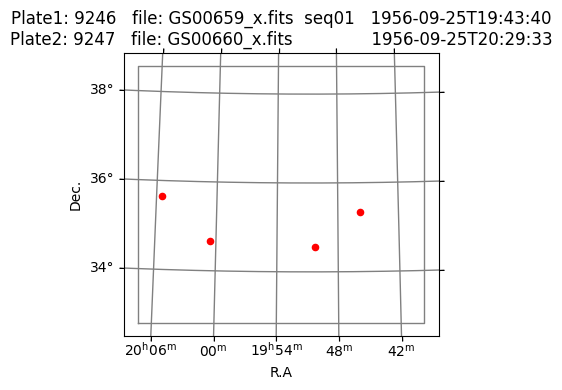

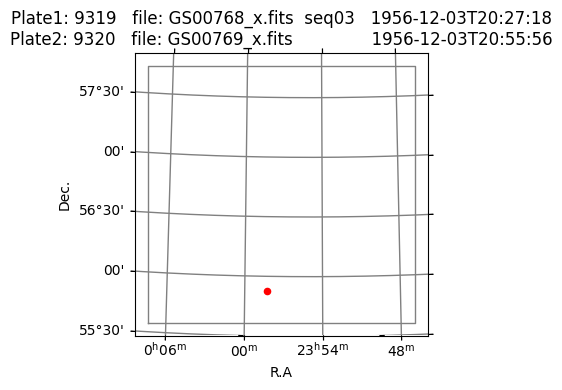

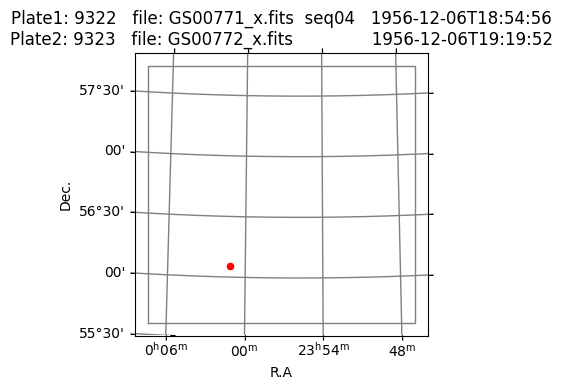

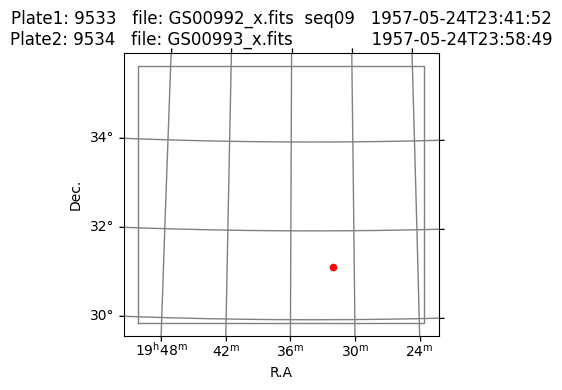

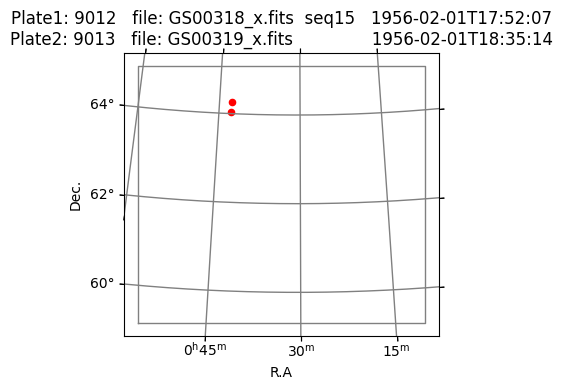

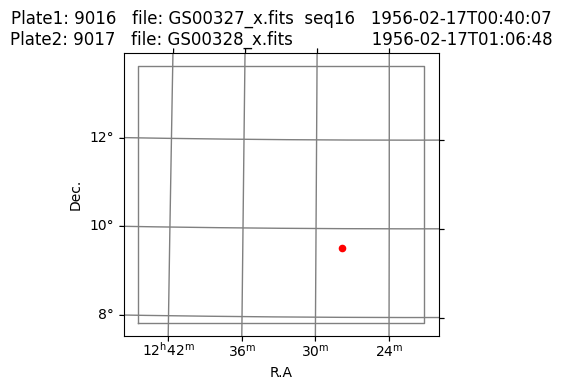

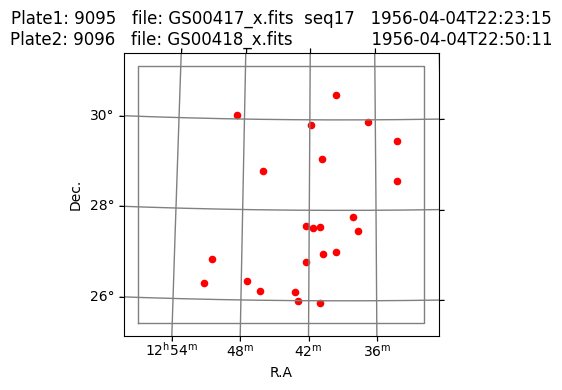

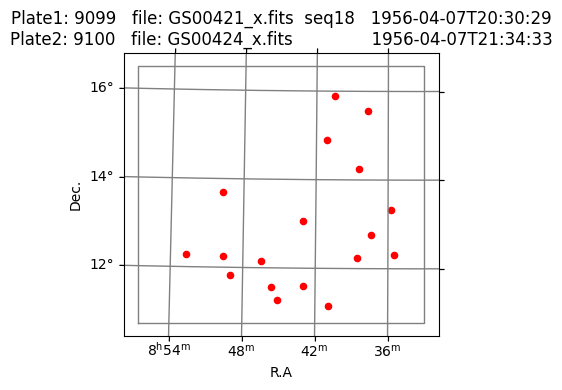

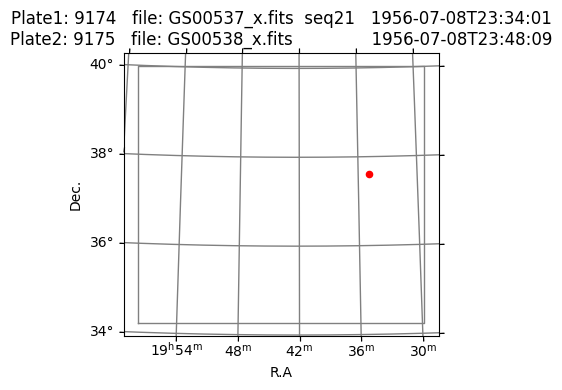

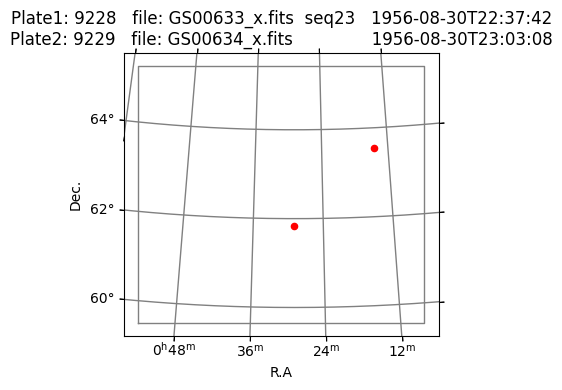

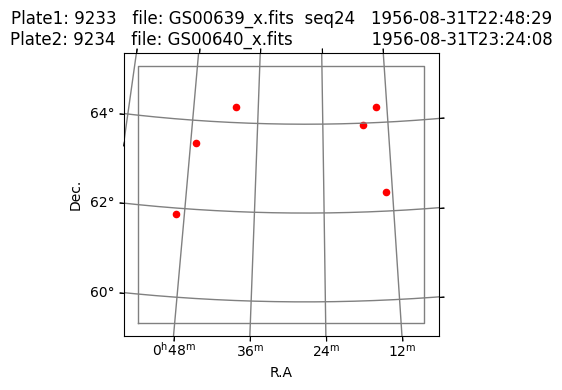

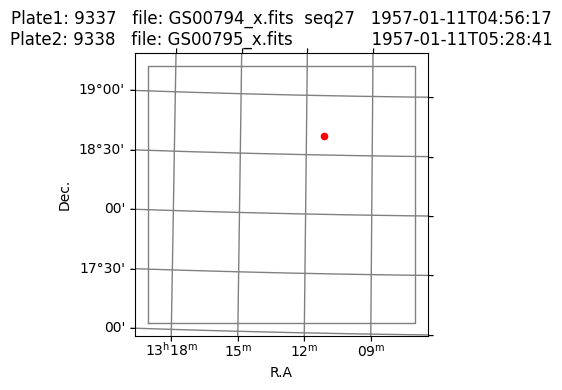

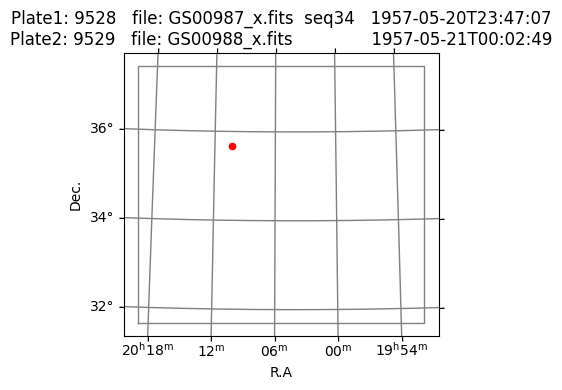

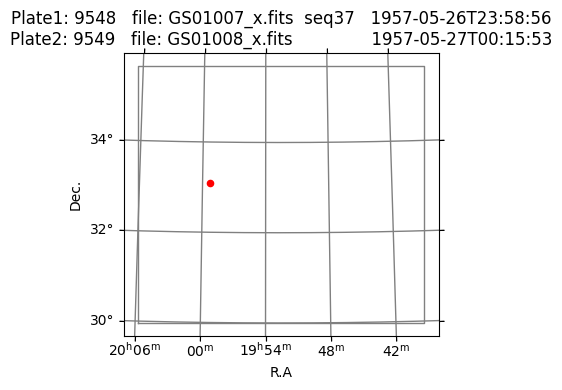

In [8]:
for plate_id in list(counter.keys()):
    plot_frame(plate_id, table_transients)

The 2 plates with a lot of transients could lead us to suspect that they could be in fact plate artifacts that still elude characterization as such. A visual and detailed exam of each one is warranted. 

Maybe artifacts caused by a bad batch of chemical developer/fixer, or a plate faulty envelope that led to contamination by dust, or something in those lines. We should check dates against the VASCO event dates, and the "atomic bomb hypothesis" and "UAP sightings hypothesis" just in case. And maybe search for more information about these plates' origins and history.

## PSF

We want to compare each transient's FWHM (and other parameters) with the same parameters from a sample of stars *from the same plate as the transient*. Looking for any systematic effect that could inform about the nature of the transients.

Code below displays these parameters (as a function of peak flux):

- ***FWHM***: width of Gaussian fit to the object.

- ***elongation***: sextractor-produced ratio between major and minor axis of ellipse fit to the object.

- ***qfit***: a quality-of-fit metric produced by the Gaussian fitting library, defined as the sum of the absolute value of the fit residuals divided by the fit flux. qfit is zero for sources that are perfectly fit by the PSF model.

- ***cfit***: a quality-of-fit metric produced by the Gaussian fitting library, defined as the fit residual (data - model) in the initial central pixel value divided by the fit flux. Large positive values indicate sources that are sharper than the PSF model (e.g., cosmic ray, hot pixel, etc.). Large negative values indicate sources that are broader than the PSF model

Code below also segregates transients into "narrow" and "stellar" categories, based on how their FWHM compares with the FWHM of similar stars of same brightness.

In [9]:
def update_linewidths(plate, linewidths, transients, reference):
    '''
    Build dict that stores subsets of source ID values corresponding to "narrow" and
    "stellar" image profiles. In each subset, source IDs are stored in lists, one list 
    per plate ID.

    Parameters:
    
    plate         - plate ID
    linewidths    - dict to be updated
    transients    - table with transients for the given plate 
    reference     - table with Gaussian-fitted stars for the given plate
    
    Returns:
    
    linewidths    - the input dictionary, updated with the transient source ID
                    for this plate
    '''
    # update result dict with empty entries for this plate
    linewidths['small_fwhm'][str(plate)] = []
    linewidths['stellar_fwhm'][str(plate)] = []
        
    half_range = 500.
    
    for row in range(len(transients)):
        source_id = transients['source_id'][row]

        # find stars in an interval of peak flux that have similar 
        # peak fluxes as the transient 
        flux_transient = transients['flux_max'][row]
        flux_low  = flux_transient - half_range
        flux_high = flux_transient + half_range

        indices = np.where((reference['flux_max'] >= flux_low) & (reference['flux_max'] <= flux_high))
        
        # get minimum FWHM among these stars
        min_fwhm = min(reference['fwhm_fit'][indices])
        
        # see if transient is narrow or stellar
        transient_fwhm = transients['fwhm_fit'][row] 
        if transient_fwhm < min_fwhm:
            key = 'small_fwhm'
        else:
            key = 'stellar_fwhm'

        # update appropriate dict with this source ID
        linewidths[key][str(plate)].append(source_id)
        
    return linewidths

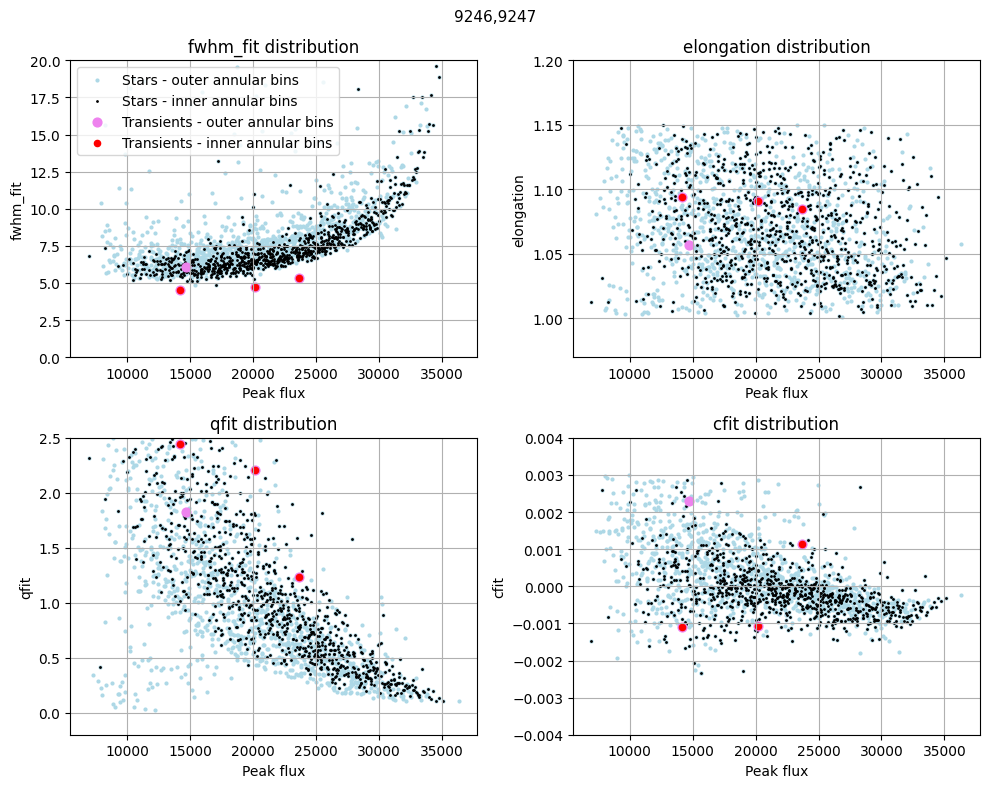

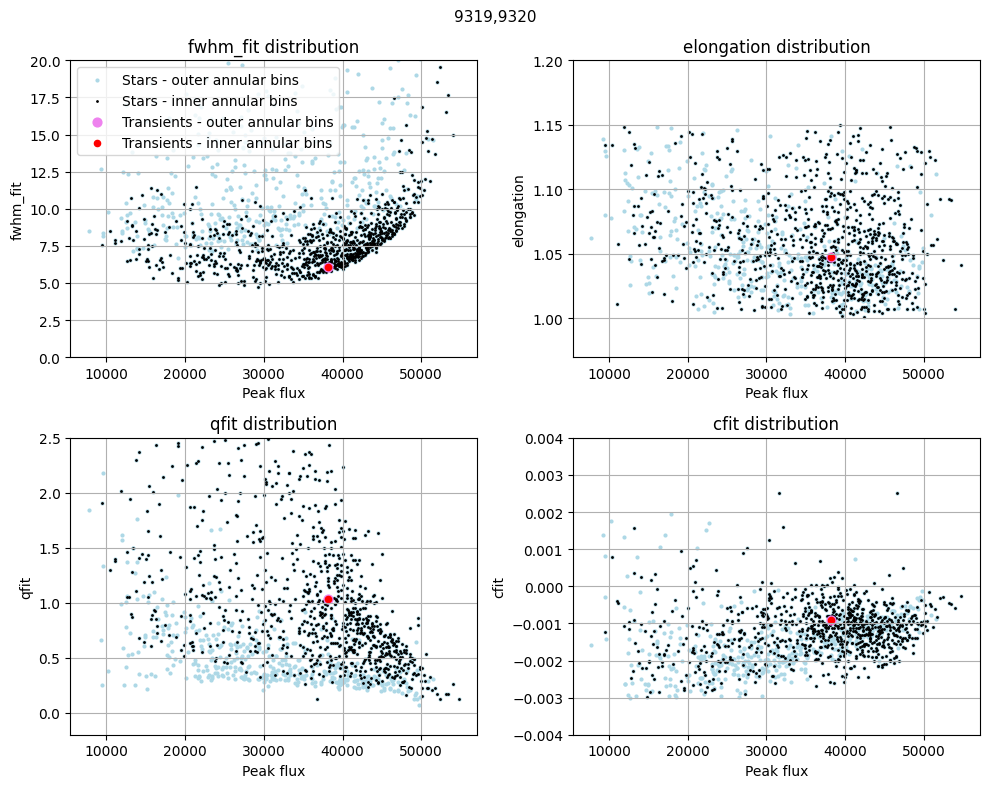

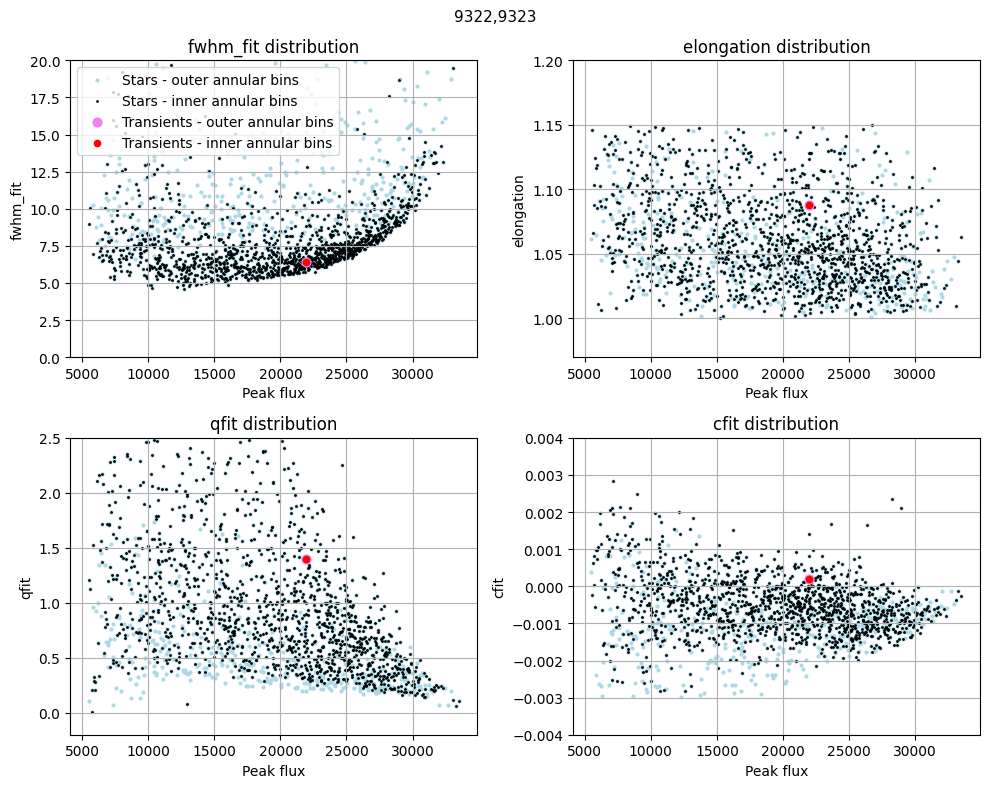

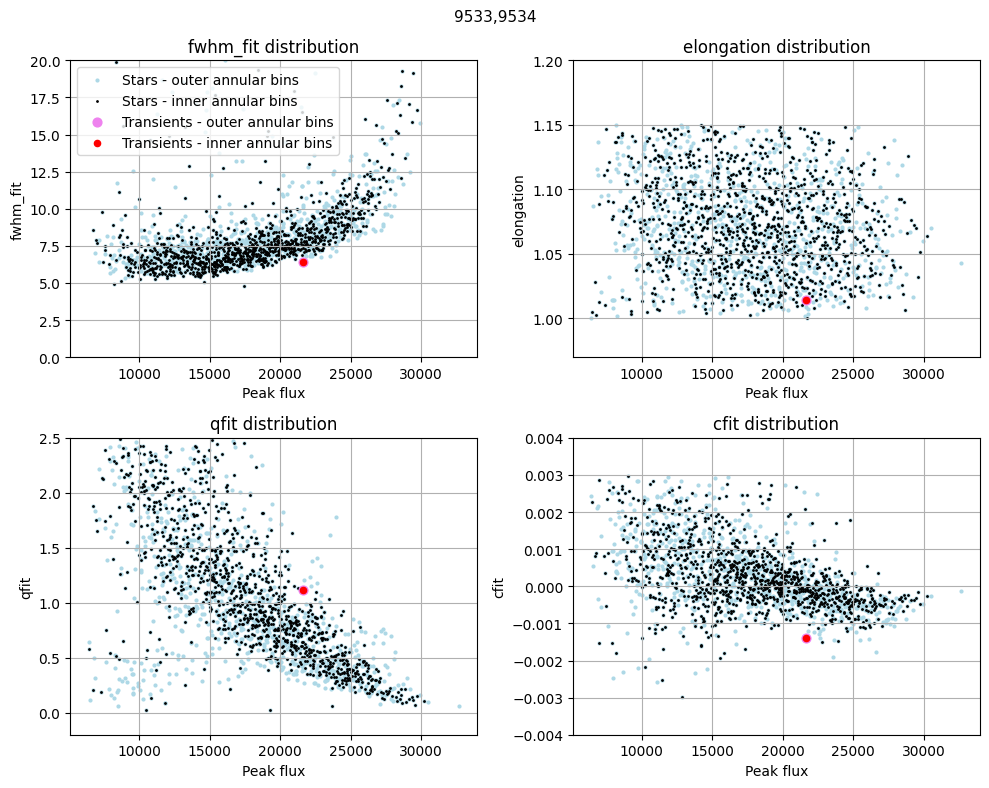

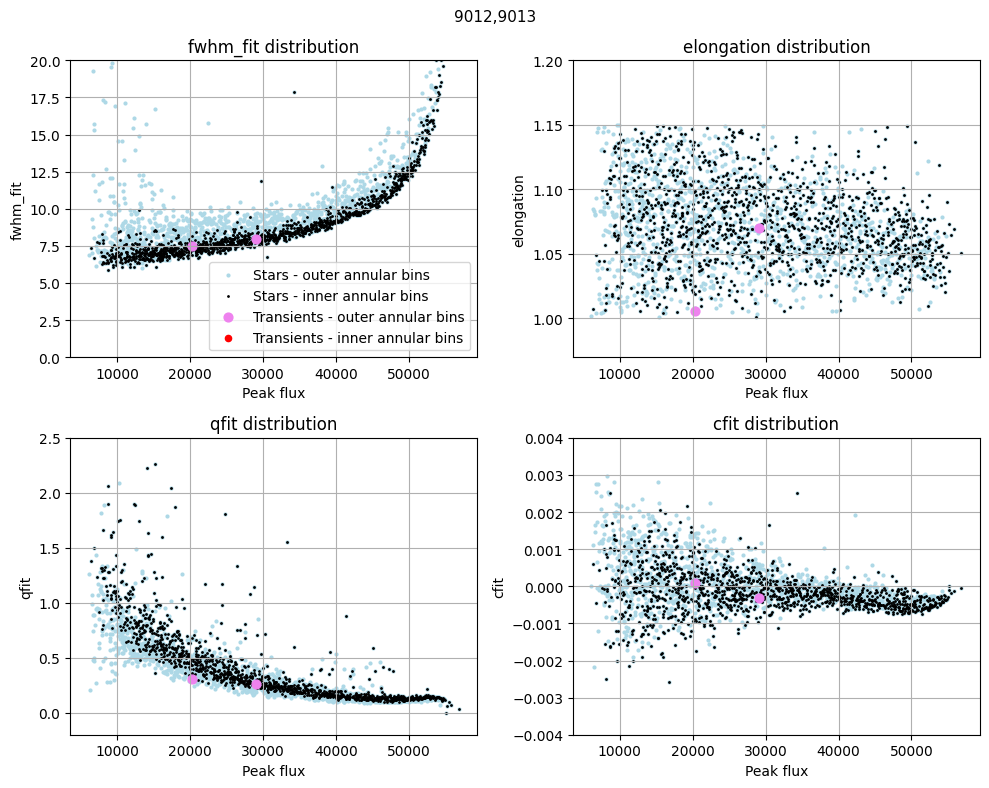

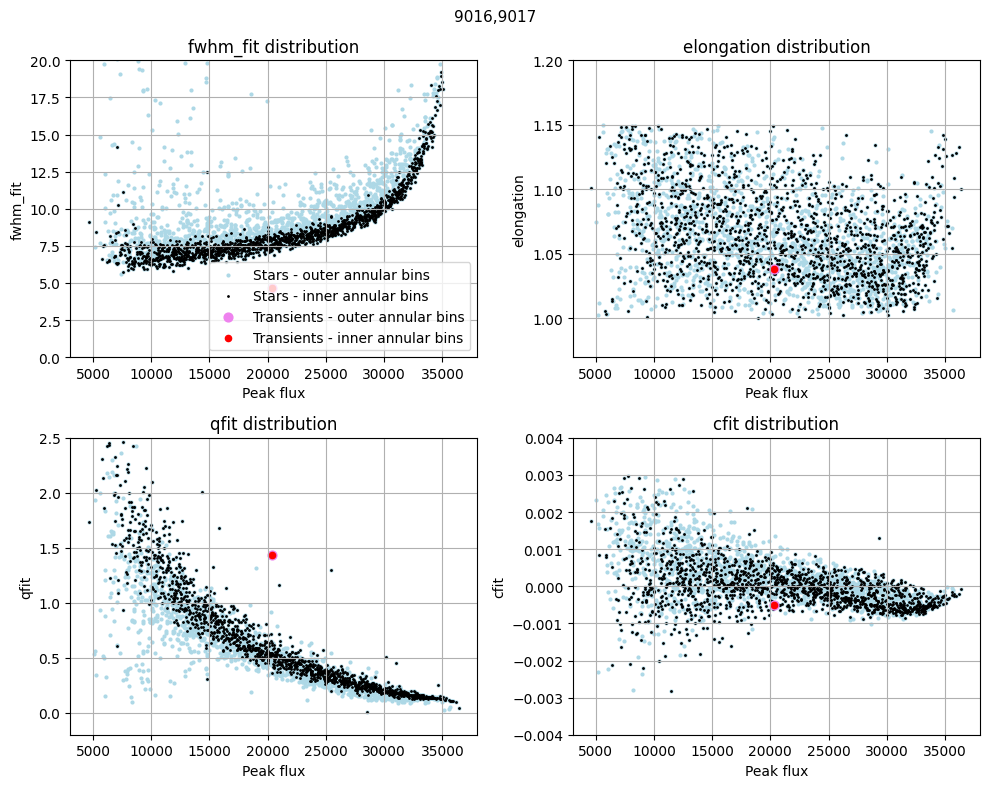

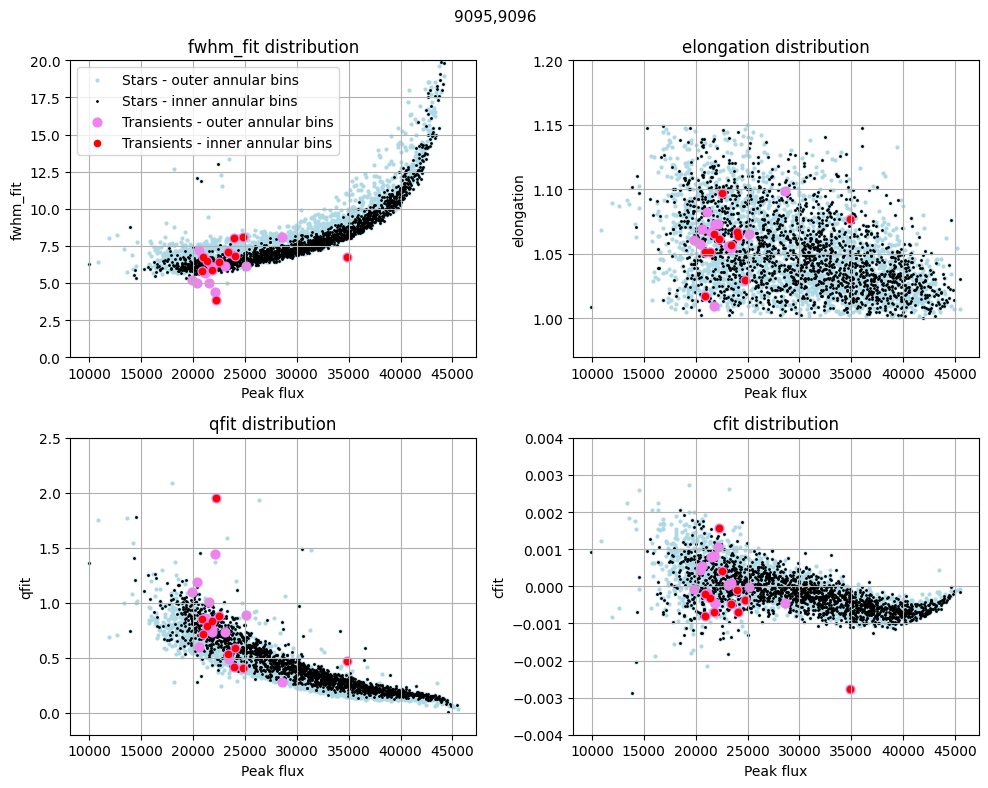

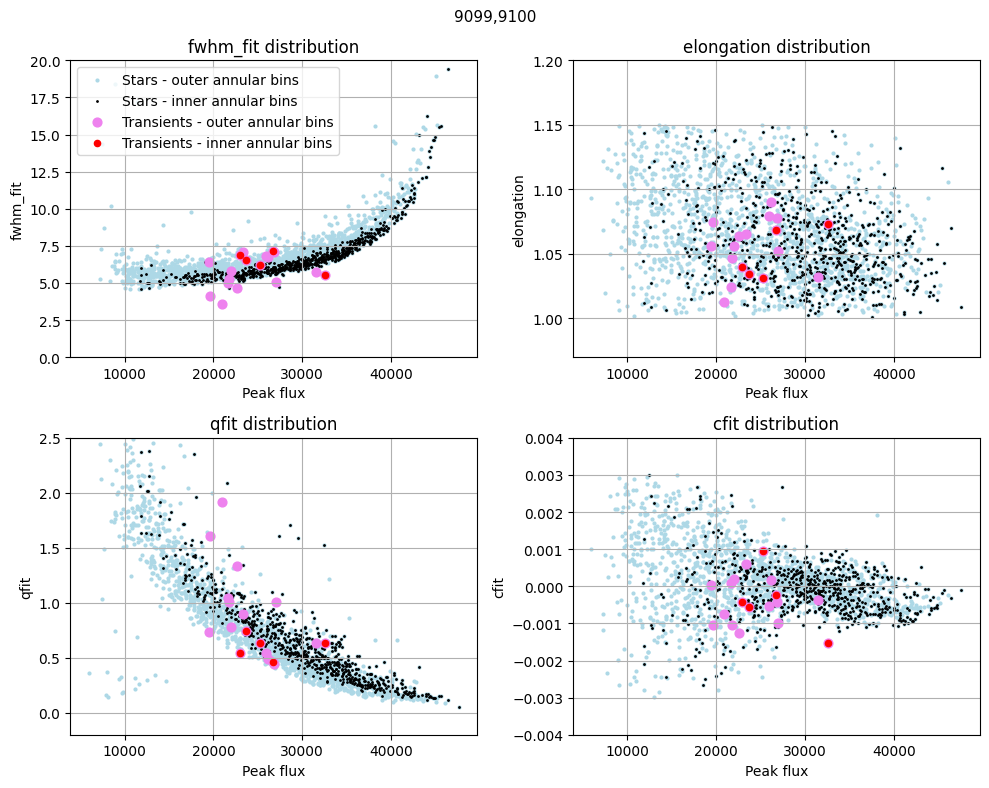

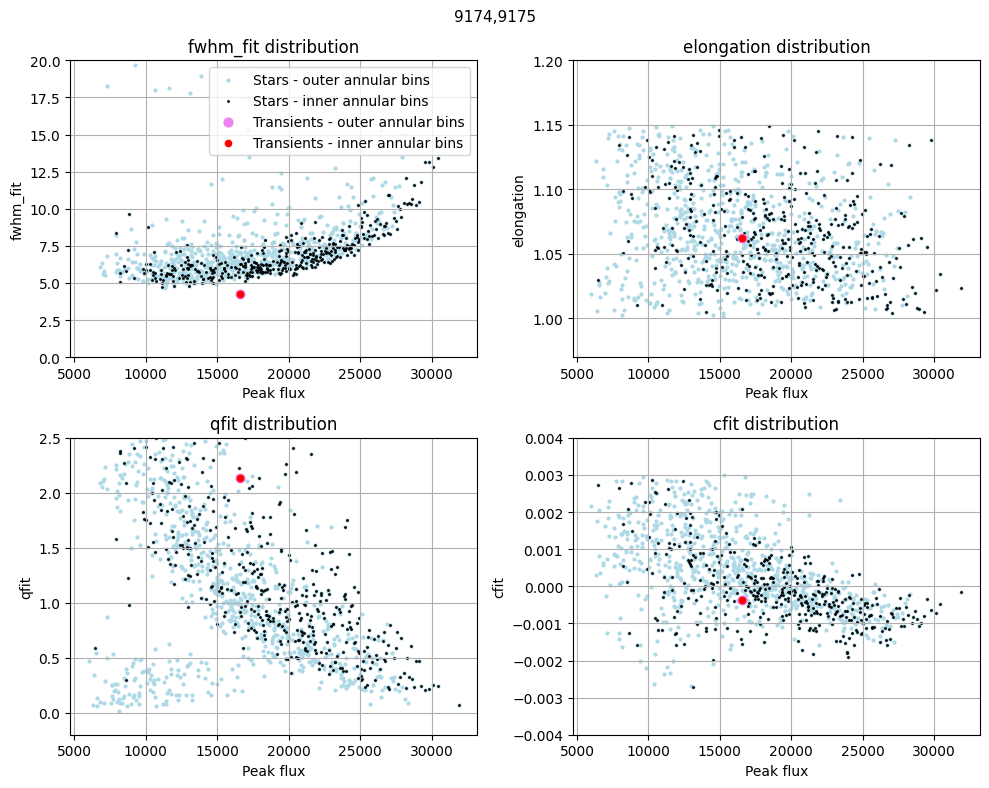

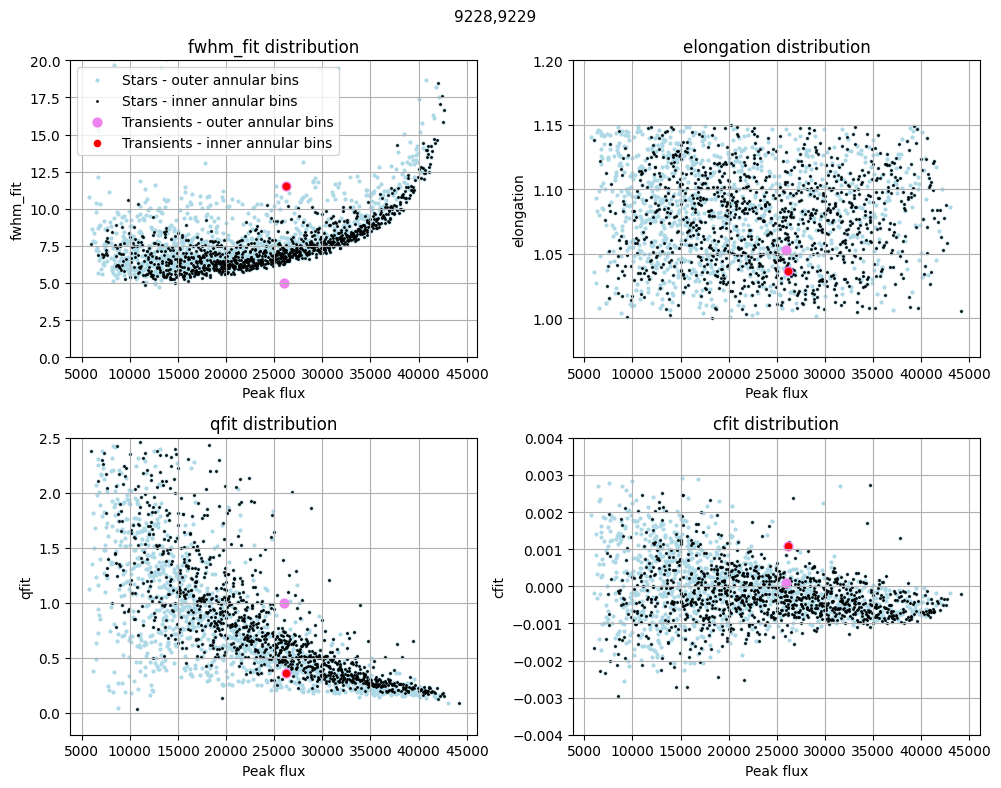

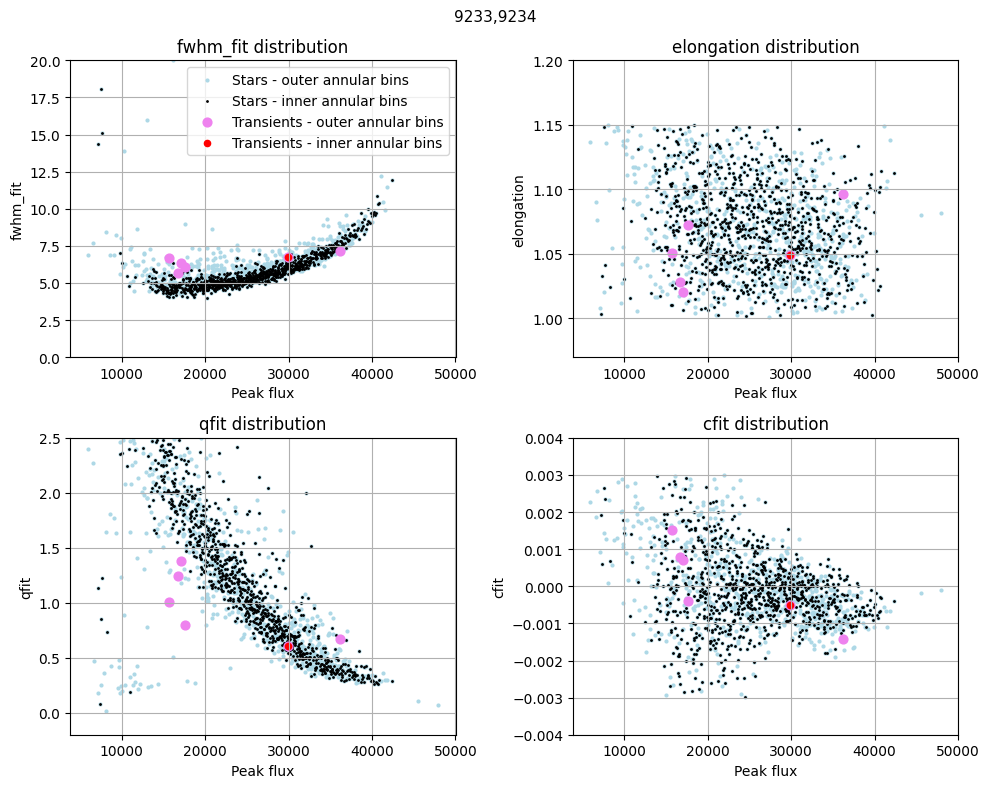

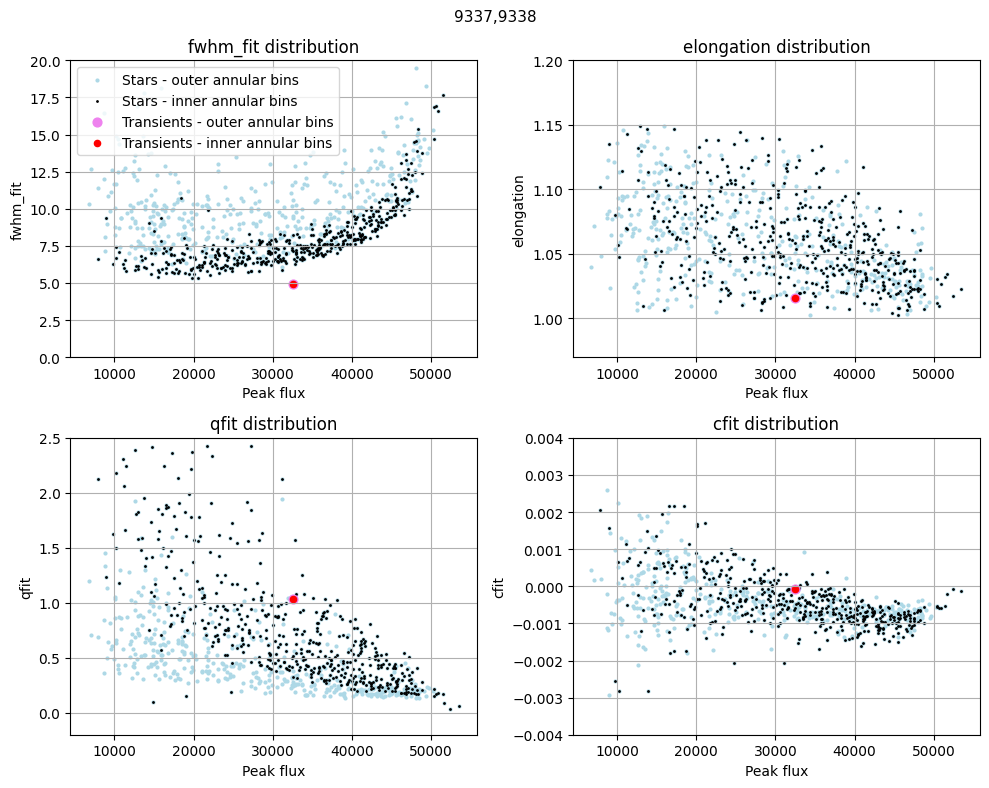

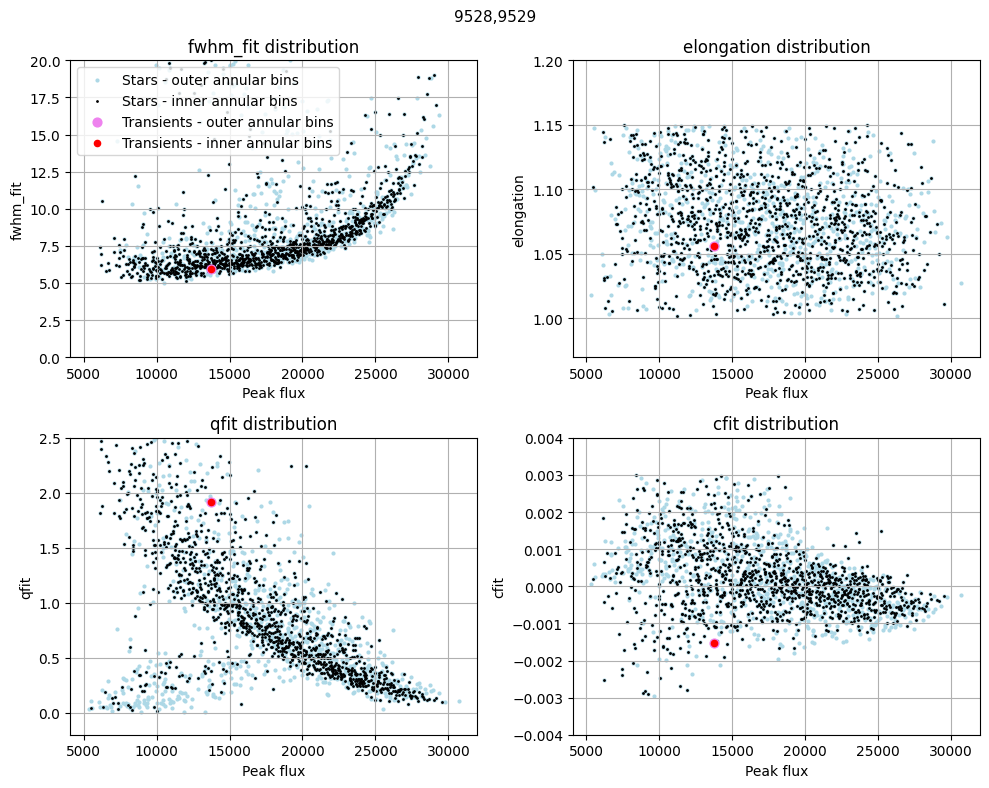

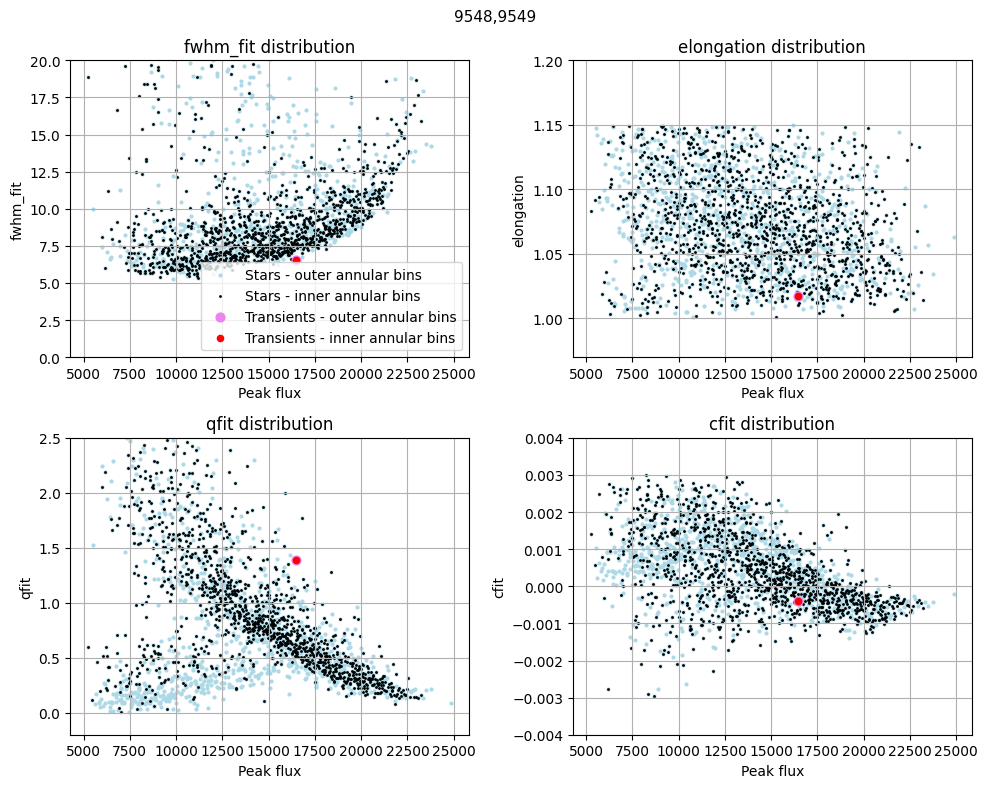

In [10]:
# this dict stores subsets of source ID values corresponding to "narrow" and
# "stellar" image profiles. In each subset, source IDs are stored in lists,
# one list per plate ID.
linewidths = {
    'small_fwhm': {},
    'stellar_fwhm': {},
}

for plate_id in list(counter.keys()):

    # isolate rows for selected plate
    mask = table_transients['plate_id_1'] == plate_id
    table_transients_plate = table_transients[mask]

    par, dataset_key = get_par(table_transients_plate)

    # finally, get table with star data    
    table_reference  = Table.read(fname(par['table_psf_matched']), format='fits')
    
    # now, it's time to plot
    _ = plot_psf_analysis([table_reference, table_transients_plate], par, title=dataset_key,
                      labels=[['Stars - outer annular bins', 'Stars - inner annular bins'], 
                              ['Transients - outer annular bins', 'Transients - inner annular bins']],
                       sizes = [[4, 1], [40, 20]])

#     for row in range(len(table_transients_plate)):
#         print(table_transients_plate['flux_max'][row], table_transients_plate['fwhm_fit'][row], 
#               table_transients_plate['source_id'][row])
        
    # update linewidths dict with data from this plate  
    linewidths = update_linewidths(plate_id, linewidths, table_transients_plate, table_reference)

    print()
    print()

### Discussion:

One can see a significant number of transients that have a smaller FWHM than stars of same brightness. Their shapes (qfit) tend to depart from a Gaussian more than a typical star image does. 

The narrower, the more they depart from the qfit=0 locus. There are quite a few counterexamples in several plates, where transients have FWHM values indistinguishable from stars, and also shapes closer to Gaussian.

So, maybe we are facing two classes of objects? One of them might be just plate artifacts not yet accounted for? It would be informative to segregate objects in these two classes based on the diagrams above, and then look at their images on the sky.

**Note**: the systematic difference seen in stars at inner and outer annular bins (Applause concept to measure distance to center of plate) is caused by slight defocussing (likely the glass plate was not bent to the exact shape of the focal surface). The effect can be seen very clearly in a few plates, in which the analysis included only the more central annular bins ("inner" and "outer" mean the inner and outer half of the range of annular bins actually included in the analysis).




### Two populations

Lets separate the two cases mentioned above:

- transient FWHM visibly smaller than star's
- transient FWHM similar to star's

These are implemented by function *update_linewidths* defined above.

Now we look at the transients themselves, with plots grouped together by class of FWHM.

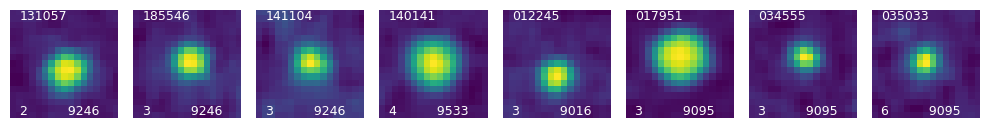

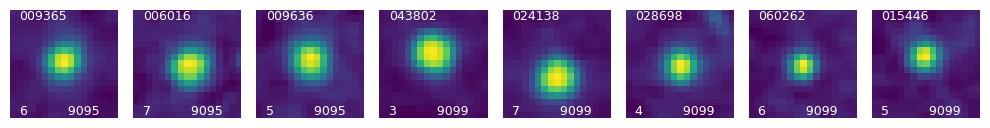

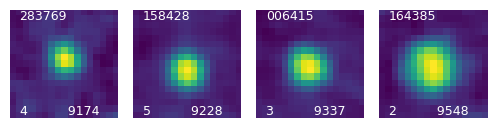

----------------------------------------------------------------------


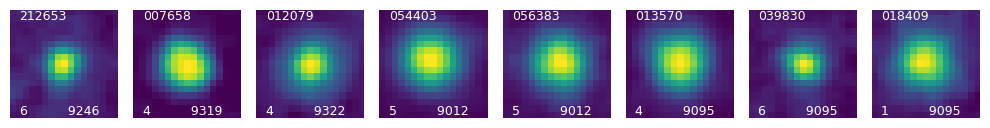

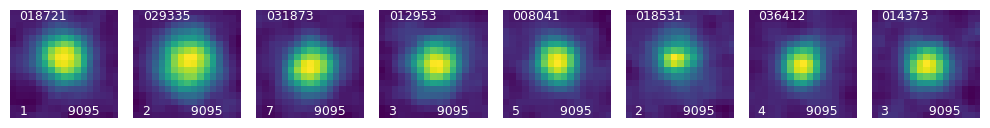

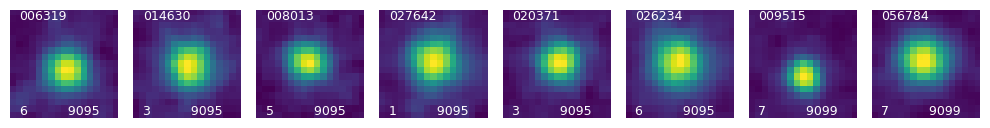

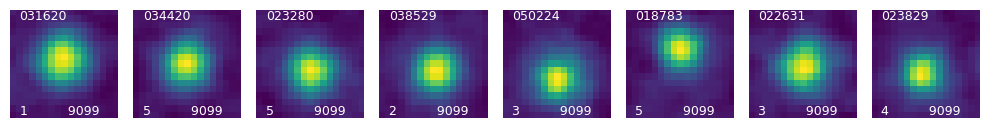

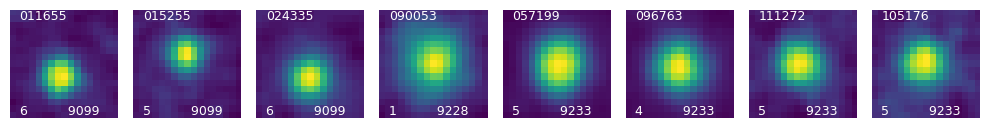

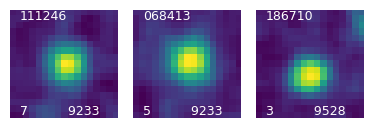

In [11]:
plates = linewidths['small_fwhm']
plot_cutout_series(plates, table_transients, images, None)
print('----------------------------------------------------------------------')
plates = linewidths['stellar_fwhm']
plot_cutout_series(plates, table_transients, images, None)

The first set above contains the narrow transients; the second set, the transients with widths indistinguishable from stars in the same plate, with same brightness. The *qfit* plots at the top of the PSF section also tell us that transients in the second set have shapes closer to a Gaussian shape, than transients in the first set (although both transients *and* stars have somewhat non-Gaussian shapes, with the difference from a Gaussian being dependent on brightness - an expected outcome given the non-linearity of photographic plates).

The numbers in each thumbnail plot are:

- **top**: source ID

- **bottom left**: the *annular_bin* where the transient is found on the plate. That's an APPLAUSE concept that encodes the distance from the plate center, 1 being closest to the center, up to 9 at the edge. Because at the edge the camera focus can be a little off, and because there is evidence (cite?) that plate edges tend to hold more artifacts, we can use it to help in telling apart "true" transients from artifacts. 

- **bottom right**: plate Id

I cannot see any significant difference in between the two groups, aside from the (expected) fact that the second group has in general fuzzier images with more of an extended halo. A few cases seem to suggest a slight asymetry in the central region, but examining them against similar plots of stars in the neighborhood, it is difficult to reject them based solely on that impression.

For comparison with actual star images, the pipeline output files in subdirectory *results/* show similar thumbnail images for each comparison star used with each transient.  

For now, we can not rule out the hypothesis that these transients are real, caused by light that passed thru the optics. Afaik, we lack an hypothesis to explain how plate artifacts, or scanner effects, would cause such star-like images. 